<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Modelo de lenguaje con tokenización por caracteres

### Consigna
- Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.
- Realizar el pre-procesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.
- Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.
- Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de greedy search y beam search determístico y estocástico. En este último caso observar el efecto de la temperatura en la generación de secuencias.


### Sugerencias
- Durante el entrenamiento, guiarse por el descenso de la perplejidad en los datos de validación para finalizar el entrenamiento. Para ello se provee un callback.
- Explorar utilizar SimpleRNN (celda de Elman), LSTM y GRU.
- rmsprop es el optimizador recomendado para la buena convergencia. No obstante se pueden explorar otros.


In [ ]:
import random
import io
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from tensorflow import keras
from tensorflow.keras import layers
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, LSTM, Embedding, Dropout
from tensorflow.keras.losses import SparseCategoricalCrossentropy

### Datos
Utilizaremos como dataset canciones de bandas de habla inglés.

In [ ]:
# descargar de textos.info
import urllib.request

# Para leer y parsear el texto en HTML de wikipedia
import bs4 as bs

In [ ]:
raw_html = urllib.request.urlopen('https://www.textos.info/julio-verne/la-vuelta-al-mundo-en-80-dias/ebook')
raw_html = raw_html.read()

# Parsear artículo, 'lxml' es el parser a utilizar
article_html = bs.BeautifulSoup(raw_html, 'lxml')

# Encontrar todos los párrafos del HTML (bajo el tag <p>)
# y tenerlos disponible como lista
article_paragraphs = article_html.find_all('p')

article_text = ''

for para in article_paragraphs:
    article_text += para.text + ' '

# pasar todo el texto a minúscula
article_text = article_text.lower()

In [ ]:
# en article text se encuentra el texto de todo el libro
article_text[:1000]

' en el año 1872, la casa número 7 de saville-row, burlington gardens \n—donde murió sheridan en 1814— estaba habitada por phileas fogg, quien a\n pesar de que parecía haber tomado el partido de no hacer nada que \npudiese llamar la atención, era uno de los miembros más notables y \nsingulares del reformclub de londres. por consiguiente, phileas fogg, personaje enigmático y del cual sólo \nse sabía que era un hombre muy galante y de los más cumplidos gentlemen \nde la alta sociedad inglesa, sucedía a uno de los más grandes oradores \nque honran a inglaterra. decíase que se daba un aire a lo byron —su cabeza, se entiende, \nporque, en cuanto a los pies, no tenía defecto alguno—, pero a un byron \nde bigote y pastillas, a un byron impasible, que hubiera vivido mil años\n sin envejecer. phileas fogg, era inglés de pura cepa; pero quizás no había nacido en\n londres. jamás se le había visto en la bolsa ni en el banco, ni en \nninguno de los despachos mercantiles de la city. ni las dársenas

### Elegir el tamaño del contexto

En este caso, como el modelo de lenguaje es por caracteres, todo un gran corpus
de texto puede ser considerado un documento en sí mismo y el tamaño de contexto
puede ser elegido con más libertad en comparación a un modelo de lenguaje tokenizado por palabras y dividido en documentos más acotados.

In [ ]:
# seleccionamos el tamaño de contexto
max_context_size = 100

In [ ]:
# Usaremos las utilidades de procesamiento de textos y secuencias de Keras
from tensorflow.keras.utils import pad_sequences # se utilizará para padding

In [ ]:
# en este caso el vocabulario es el conjunto único de caracteres que existe en todo el texto
chars_vocab = set(article_text)

In [ ]:
# la longitud de vocabulario de caracteres es:
len(chars_vocab)

In [ ]:
# Construimos los dicionarios que asignan índices a caracteres y viceversa.
# El diccionario `char2idx` servirá como tokenizador.
char2idx = {k: v for v,k in enumerate(chars_vocab)}
idx2char = {v: k for k,v in char2idx.items()}

###  Tokenizar

In [ ]:
# tokenizamos el texto completo
tokenized_text = [char2idx[ch] for ch in article_text]

In [ ]:
tokenized_text[:1000]

### Organizando y estructurando el dataset

In [ ]:
# separaremos el dataset entre entrenamiento y validación.
# `p_val` será la proporción del corpus que se reservará para validación
# `num_val` es la cantidad de secuencias de tamaño `max_context_size` que se usará en validación
p_val = 0.1
num_val = int(np.ceil(len(tokenized_text)*p_val/max_context_size))

NameError: name 'max_context_size' is not defined

In [ ]:
# separamos la porción de texto utilizada en entrenamiento de la de validación.
train_text = tokenized_text[:-num_val*max_context_size]
val_text = tokenized_text[-num_val*max_context_size:]

In [ ]:
tokenized_sentences_val = [val_text[init*max_context_size:init*(max_context_size+1)] for init in range(num_val)]

In [ ]:
tokenized_sentences_train = [train_text[init:init+max_context_size] for init in range(len(train_text)-max_context_size+1)]

In [ ]:
X = np.array(tokenized_sentences_train[:-1])
y = np.array(tokenized_sentences_train[1:])

Nótese que estamos estructurando el problema de aprendizaje como *many-to-many*:

Entrada: secuencia de tokens [$x_0$, $x_1$, ..., $x_N$]

Target: secuencia de tokens [$x_1$, $x_2$, ..., $x_{N+1}$]

De manera que la red tiene que aprender que su salida deben ser los tokens desplazados en una posición y un nuevo token predicho (el N+1).

La ventaja de estructurar el aprendizaje de esta manera es que para cada token de target se propaga una señal de gradiente por el grafo de cómputo recurrente, que es mejor que estructurar el problema como *many-to-one* en donde sólo una señal de gradiente se propaga.

En este punto tenemos en la variable `tokenized_sentences` los versos tokenizados. Vamos a quedarnos con un conjunto de validación que utilizaremos para medir la calidad de la generación de secuencias con la métrica de Perplejidad.

In [ ]:
X.shape

In [ ]:
X[0,:10]

In [ ]:
y[0,:10]

In [ ]:
vocab_size = len(chars_vocab)

# Definiendo el modelo

In [ ]:
from keras.layers import Input, TimeDistributed, CategoryEncoding, SimpleRNN, Dense
from keras.models import Model, Sequential

El modelo que se propone como ejemplo consume los índices de los tokens y los transforma en vectores OHE (en este caso no entrenamos una capa de embedding para caracteres). Esa transformación se logra combinando las capas `CategoryEncoding` que transforma a índices a vectores OHE y `TimeDistributed` que aplica la capa a lo largo de la dimensión "temporal" de la secuencia.

In [ ]:
model = Sequential()

model.add(TimeDistributed(CategoryEncoding(num_tokens=vocab_size, output_mode = "one_hot"),input_shape=(None,1)))
model.add(SimpleRNN(200, return_sequences=True, dropout=0.1, recurrent_dropout=0.1 ))
model.add(Dense(vocab_size, activation='softmax'))
model.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')

model.summary()


### Definir el modelo

Dado que por el momento no hay implementaciones adecuadas de la perplejidad que puedan operar en tiempo de entrenamiento, armaremos un Callback *ad-hoc* que la calcule en cada epoch.

**Nota**: un Callback es una rutina gatillada por algún evento, son muy útiles para relevar datos en diferentes momentos del desarrollo del modelo. En este caso queremos hacer un cálculo cada vez que termina una epoch de entrenamiento.

In [ ]:
class PplCallback(keras.callbacks.Callback):

    '''
    Este callback es una solución ad-hoc para calcular al final de cada epoch de
    entrenamiento la métrica de Perplejidad sobre un conjunto de datos de validación.
    La perplejidad es una métrica cuantitativa para evaluar la calidad de la generación de secuencias.
    Además implementa la finalización del entrenamiento (Early Stopping)
    si la perplejidad no mejora después de `patience` epochs.
    '''

    def __init__(self, val_data, history_ppl,patience=5):
      # El callback lo inicializamos con secuencias de validación sobre las cuales
      # mediremos la perplejidad
      self.val_data = val_data

      self.target = []
      self.padded = []

      count = 0
      self.info = []
      self.min_score = np.inf
      self.patience_counter = 0
      self.patience = patience

      # nos movemos en todas las secuencias de los datos de validación
      for seq in self.val_data:

        len_seq = len(seq)
        # armamos todas las subsecuencias
        subseq = [seq[:i] for i in range(1,len_seq)]
        self.target.extend([seq[i] for i in range(1,len_seq)])

        if len(subseq)!=0:

          self.padded.append(pad_sequences(subseq, maxlen=max_context_size, padding='pre'))

          self.info.append((count,count+len_seq))
          count += len_seq

      self.padded = np.vstack(self.padded)


    def on_epoch_end(self, epoch, logs=None):

        # en `scores` iremos guardando la perplejidad de cada secuencia
        scores = []

        predictions = self.model.predict(self.padded,verbose=0)

        # para cada secuencia de validación
        for start,end in self.info:

          # en `probs` iremos guardando las probabilidades de los términos target
          probs = [predictions[idx_seq,-1,idx_vocab] for idx_seq, idx_vocab in zip(range(start,end),self.target[start:end])]

          # calculamos la perplejidad por medio de logaritmos
          scores.append(np.exp(-np.sum(np.log(probs))/(end-start)))

        # promediamos todos los scores e imprimimos el valor promedio
        current_score = np.mean(scores)
        history_ppl.append(current_score)
        print(f'\n mean perplexity: {current_score} \n')

        # chequeamos si tenemos que detener el entrenamiento
        if current_score < self.min_score:
          self.min_score = current_score
          self.model.save("my_model.keras")
          print("Saved new model!")
          self.patience_counter = 0
        else:
          self.patience_counter += 1
          if self.patience_counter == self.patience:
            print("Stopping training...")
            self.model.stop_training = True


### Entrenamiento

In [ ]:
# fiteamos, nótese el agregado del callback con su inicialización. El batch_size lo podemos seleccionar a mano
# en general, lo mejor es escoger el batch más grande posible que minimice el tiempo de cada época.
# En la variable `history_ppl` se guardarán los valores de perplejidad para cada época.
history_ppl = []
hist = model.fit(X, y, epochs=20, callbacks=[PplCallback(tokenized_sentences_val,history_ppl)], batch_size=256)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Entrenamiento
epoch_count = range(1, len(history_ppl) + 1)
sns.lineplot(x=epoch_count,  y=history_ppl)
plt.show()

In [ ]:
# Cargamos el mejor modelo guardado del entrenamiento para hacer inferencia
model = keras.models.load_model('my_model.keras')


### Predicción del próximo caracter

In [ ]:
# Se puede usar gradio para probar el modelo
# Gradio es una herramienta muy útil para crear interfaces para ensayar modelos
# https://gradio.app/

!pip install -q gradio

In [ ]:
import gradio as gr

def model_response(human_text):

    # Encodeamos
    encoded = [char2idx[ch] for ch in human_text.lower() ]
    # Si tienen distinto largo
    encoded = pad_sequences([encoded], maxlen=max_context_size, padding='pre')

    # Predicción softmax
    y_hat = np.argmax(model.predict(encoded)[0,-1,:])


    # Debemos buscar en el vocabulario el caracter
    # que corresopnde al indice (y_hat) predicho por le modelo
    out_word = ''
    out_word = idx2char[y_hat]

    # Agrego la palabra a la frase predicha
    return human_text + out_word

iface = gr.Interface(
    fn=model_response,
    inputs=["textbox"],
    outputs="text")

iface.launch(debug=True)

### Generación de secuencias

In [ ]:
def generate_seq(model, seed_text, max_length, n_words):
    """
        Exec model sequence prediction

        Args:
            model (keras): modelo entrenado
            seed_text (string): texto de entrada (input_seq)
            max_length (int): máxima longitud de la sequencia de entrada
            n_words (int): números de caracteres a agregar a la sequencia de entrada
        returns:
            output_text (string): sentencia con las "n_words" agregadas
    """
    output_text = seed_text
	# generate a fixed number of words
    for _ in range(n_words):
		# Encodeamos
        encoded = [char2idx[ch] for ch in output_text.lower() ]
		# Si tienen distinto largo
        encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

		# Predicción softmax
        y_hat = np.argmax(model.predict(encoded,verbose=0)[0,-1,:])
		# Vamos concatenando las predicciones
        out_word = ''

        out_word = idx2char[y_hat]

		# Agrego las palabras a la frase predicha
        output_text += out_word
    return output_text

In [ ]:
input_text='habia una vez'

generate_seq(model, input_text, max_length=max_context_size, n_words=30)

###  Beam search y muestreo aleatorio

In [ ]:
# funcionalidades para hacer encoding y decoding

def encode(text,max_length=max_context_size):

    encoded = [char2idx[ch] for ch in text]
    encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

    return encoded

def decode(seq):
    return ''.join([idx2char[ch] for ch in seq])

In [ ]:
from scipy.special import softmax

# función que selecciona candidatos para el beam search
def select_candidates(pred,num_beams,vocab_size,history_probs,history_tokens,temp,mode):

  # colectar todas las probabilidades para la siguiente búsqueda
  pred_large = []

  for idx,pp in enumerate(pred):
    pred_large.extend(np.log(pp+1E-10)+history_probs[idx])

  pred_large = np.array(pred_large)

  # criterio de selección
  if mode == 'det':
    idx_select = np.argsort(pred_large)[::-1][:num_beams] # beam search determinista
  elif mode == 'sto':
    idx_select = np.random.choice(np.arange(pred_large.shape[0]), num_beams, p=softmax(pred_large/temp)) # beam search con muestreo aleatorio
  else:
    raise ValueError(f'Wrong selection mode. {mode} was given. det and sto are supported.')

  # traducir a índices de token en el vocabulario
  new_history_tokens = np.concatenate((np.array(history_tokens)[idx_select//vocab_size],
                        np.array([idx_select%vocab_size]).T),
                      axis=1)

  # devolver el producto de las probabilidades (log) y la secuencia de tokens seleccionados
  return pred_large[idx_select.astype(int)], new_history_tokens.astype(int)


def beam_search(model,num_beams,num_words,input,temp=1,mode='det'):

    # first iteration

    # encode
    encoded = encode(input)

    # first prediction
    y_hat = model.predict(encoded,verbose=0)[0,-1,:]

    # get vocabulary size
    vocab_size = y_hat.shape[0]

    # initialize history
    history_probs = [0]*num_beams
    history_tokens = [encoded[0]]*num_beams

    # select num_beams candidates
    history_probs, history_tokens = select_candidates([y_hat],
                                        num_beams,
                                        vocab_size,
                                        history_probs,
                                        history_tokens,
                                        temp,
                                        mode)

    # beam search loop
    for i in range(num_words-1):

      preds = []

      for hist in history_tokens:

        # actualizar secuencia de tokens
        input_update = np.array([hist[i+1:]]).copy()

        # predicción
        y_hat = model.predict(input_update,verbose=0)[0,-1,:]

        preds.append(y_hat)

      history_probs, history_tokens = select_candidates(preds,
                                                        num_beams,
                                                        vocab_size,
                                                        history_probs,
                                                        history_tokens,
                                                        temp,
                                                        mode)

    return history_tokens[:,-(len(input)+num_words):]

In [ ]:
# predicción con beam search
salidas = beam_search(model,num_beams=10,num_words=20,input="habia una vez")

In [ ]:
salidas[0]

In [ ]:
# veamos las salidas
decode(salidas[0])

**DESAFIO 3**

In [ ]:
import pandas as pd
import numpy as np
import re
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
!pip install gdown

In [ ]:
import gdown

url = "https://drive.google.com/uc?id=1fHTz9YECbhrZwi3vzz82FyiBUOrTJjOy"

gdown.download(url, "songs.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1fHTz9YECbhrZwi3vzz82FyiBUOrTJjOy
To: /content/songs.csv
100%|██████████| 74.9M/74.9M [00:00<00:00, 188MB/s]


'songs.csv'

In [ ]:
df = pd.read_csv("songs.csv")

# filtrar artista
df_artist = df[df["artist"] == "Coldplay"]

# unir todas las canciones
article_text = " ".join(df_artist["text"].astype(str))

# pasar a minúsculas
article_text = article_text.lower()

import re
article_text = re.sub(r"\[.*?\]", "", article_text)
article_text = re.sub(r"\n", " ", article_text)
article_text = re.sub(r"\s+", " ", article_text)
#No se eliminaron signos de puntuación ya que aportan información relevante sobre la estructura del lenguaje.

print(article_text[:1000])

late night watching tv used to be you here beside me used to be your arms around me your body on my body when the world means nothing to me another's arms, another's arms when the pain just rips right through me another's arms, another's arms late night watching tv used to be you here beside me is there someone there to reach me? someone there to find me? when the pain just rips right through me another's arms, another's arms and that's just torture to me another's arms, another's arms pull yourself into me another's arms, another's arms when the world means nothing to me another's arms, another's arms got to pull you close into me another's arms, another's arms pull yourself right through me another's arms, another's arms late night watching tv wish that you were here beside me wish that your arms were around me your body on my body i want to be bigger stronger drive a faster car to take me anywhere in seconds to take me anywhere i want to go and drive around a faster car i will settl

In [ ]:
print(len(article_text))

119512


In [ ]:
# seleccionamos el tamaño de contexto
max_context_size = 100

In [ ]:
chars_vocab = sorted(list(set(article_text))) #En vez de set(article_text)
char2idx = {k:v for v,k in enumerate(chars_vocab)}
idx2char = {v:k for k,v in char2idx.items()}
vocab_size = len(chars_vocab)

print(chars_vocab)

[' ', '!', '"', "'", '(', ')', ',', '-', '.', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', '?', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


###  Tokenizar

In [ ]:
# tokenizamos el texto completo
tokenized_text = [char2idx[ch] for ch in article_text]

In [ ]:
tokenized_text[:1000]

[32,
 21,
 40,
 25,
 0,
 34,
 29,
 27,
 28,
 40,
 0,
 43,
 21,
 40,
 23,
 28,
 29,
 34,
 27,
 0,
 40,
 42,
 0,
 41,
 39,
 25,
 24,
 0,
 40,
 35,
 0,
 22,
 25,
 0,
 45,
 35,
 41,
 0,
 28,
 25,
 38,
 25,
 0,
 22,
 25,
 39,
 29,
 24,
 25,
 0,
 33,
 25,
 0,
 41,
 39,
 25,
 24,
 0,
 40,
 35,
 0,
 22,
 25,
 0,
 45,
 35,
 41,
 38,
 0,
 21,
 38,
 33,
 39,
 0,
 21,
 38,
 35,
 41,
 34,
 24,
 0,
 33,
 25,
 0,
 45,
 35,
 41,
 38,
 0,
 22,
 35,
 24,
 45,
 0,
 35,
 34,
 0,
 33,
 45,
 0,
 22,
 35,
 24,
 45,
 0,
 43,
 28,
 25,
 34,
 0,
 40,
 28,
 25,
 0,
 43,
 35,
 38,
 32,
 24,
 0,
 33,
 25,
 21,
 34,
 39,
 0,
 34,
 35,
 40,
 28,
 29,
 34,
 27,
 0,
 40,
 35,
 0,
 33,
 25,
 0,
 21,
 34,
 35,
 40,
 28,
 25,
 38,
 3,
 39,
 0,
 21,
 38,
 33,
 39,
 6,
 0,
 21,
 34,
 35,
 40,
 28,
 25,
 38,
 3,
 39,
 0,
 21,
 38,
 33,
 39,
 0,
 43,
 28,
 25,
 34,
 0,
 40,
 28,
 25,
 0,
 36,
 21,
 29,
 34,
 0,
 30,
 41,
 39,
 40,
 0,
 38,
 29,
 36,
 39,
 0,
 38,
 29,
 27,
 28,
 40,
 0,
 40,
 28,
 38,
 35,
 41,
 27,
 28,
 0,

### Organizando y estructurando el dataset

In [ ]:
# separaremos el dataset entre entrenamiento y validación.
# `p_val` será la proporción del corpus que se reservará para validación
# `num_val` es la cantidad de secuencias de tamaño `max_context_size` que se usará en validación
p_val = 0.1
num_val = int(np.ceil(len(tokenized_text)*p_val/max_context_size))

In [ ]:
# separamos la porción de texto utilizada en entrenamiento de la de validación.
train_text = tokenized_text[:-num_val*max_context_size]
val_text = tokenized_text[-num_val*max_context_size:]

In [ ]:
tokenized_sentences_val = [val_text[init*max_context_size:init*(max_context_size+1)] for init in range(num_val)]
tokenized_sentences_train = [train_text[init:init+max_context_size] for init in range(len(train_text)-max_context_size+1)]
X = np.array(tokenized_sentences_train[:-1])
y = np.array(tokenized_sentences_train[1:])

In [ ]:
X.shape

(94404, 100)

In [ ]:
X[0,:10]

array([32, 21, 40, 25,  0, 34, 29, 27, 28, 40])

In [ ]:
y[0,:10]

array([21, 40, 25,  0, 34, 29, 27, 28, 40,  0])

In [ ]:
vocab_size = len(chars_vocab)

# Definiendo el modelo

In [ ]:
from keras.layers import Input, TimeDistributed, CategoryEncoding, SimpleRNN, Dense
from keras.models import Model, Sequential

## Arquitectura SimpleRNN

In [ ]:
model_rnn = Sequential([
    Embedding(vocab_size, 128),
    SimpleRNN(
        256,
        return_sequences=True,
        dropout=0.2 ),
    Dense(vocab_size, activation='softmax')
])
model_rnn.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='rmsprop'
)

model_rnn.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

##Arquitectura LSTM

In [ ]:
model_lstm = Sequential([
    Embedding(vocab_size, 128),
    LSTM( 256, return_sequences=True, dropout=0.2 ),
    Dense(vocab_size, activation='softmax')
])
model_lstm.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='rmsprop'
)

model_lstm.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

##Arquitectura GRU

In [ ]:
from tensorflow.keras.optimizers import RMSprop

optimizer = RMSprop(learning_rate=0.001)

model_gru = Sequential([
    Embedding(vocab_size, 128),
    GRU( 256, return_sequences=True, dropout=0.2 ),
    Dense(vocab_size, activation='softmax')
])
model_gru.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=optimizer
)

model_gru.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
class PplCallback(keras.callbacks.Callback):

    '''
    Callback para calcular perplexity y aplicar early stopping.
    '''

    def __init__(
        self,
        history_ppl,
        model_name="model",
        patience=5
    ):

        super().__init__()

        # historial de perplexity
        self.history_ppl = history_ppl

        # nombre para guardar modelo
        self.model_name = model_name

        # early stopping
        self.min_score = np.inf

        self.patience_counter = 0

        self.patience = patience

    def on_epoch_end(self, epoch, logs=None):

        # loss calculado por Keras
        loss = logs["loss"]

        # perplexity
        current_score = np.exp(loss)

        # guardar historial
        self.history_ppl.append(current_score)

        print(f"\nMean Perplexity: {current_score:.4f}\n")

        # guardar mejor modelo
        if current_score < self.min_score:

            self.min_score = current_score

            self.model.save(
                f"{self.model_name}.keras"
            )

            print("Saved new model!")

            self.patience_counter = 0

        else:

            self.patience_counter += 1

            if self.patience_counter >= self.patience:

                print("Stopping training...")

                self.model.stop_training = True

In [ ]:
history_ppl = []
hist = model.fit(X, y, epochs=20, callbacks=[PplCallback(history_ppl)], batch_size=256)

Epoch 1/20
367/369 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.3067
Mean Perplexity: 3.6947

Saved new model!
369/369 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 1.3069
Epoch 2/20
368/369 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1.3054
Mean Perplexity: 3.6897

Saved new model!
369/369 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 1.3055
Epoch 3/20
368/369 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.3050
Mean Perplexity: 3.6936

369/369 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - loss: 1.3066
Epoch 4/20
368/369 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.3058
Mean Perplexity: 3.6897

369/369 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 1.3055
Epoch 5/20
367/369 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.3060
Mean Perplexity: 3.6885

Saved new model!
369/369 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 1.3052
Epoch 6/20
368/369 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.3061
Mean Perplexity: 3.6889

369/369 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 1.3053
Epoch 7/20
366/369 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/

In [ ]:
history_ppl_rnn = []
hist_rnn = model_rnn.fit(X, y,
                         epochs=20,
                         callbacks=[PplCallback(history_ppl_rnn,model_name="model_rnn")],
                         batch_size=256)

Epoch 1/20
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.6125
Mean Perplexity: 1.8455

Saved new model!
369/369 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - loss: 0.6128
Epoch 2/20
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.6103
Mean Perplexity: 1.8389

Saved new model!
369/369 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - loss: 0.6092
Epoch 3/20
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.6080
Mean Perplexity: 1.8332

Saved new model!
369/369 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - loss: 0.6061
Epoch 4/20
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.6048
Mean Perplexity: 1.8297

Saved new model!
369/369 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - loss: 0.6042
Epoch 5/20
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.6020
Mean Perplexity: 1.8242

Saved new model!
369/369 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - loss: 0.6012
Epoch 6/20
368/369 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.5993
Mean Perplexity: 1.8188

Saved new model!
369/369 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - loss:

In [ ]:
history_ppl_lstm = []
hist_lstm = model_lstm.fit(X, y, epochs=20, callbacks=[PplCallback(history_ppl_lstm,model_name="model_lstm")], batch_size=256)

Epoch 1/20
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.8066
Mean Perplexity: 2.2294

Saved new model!
369/369 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - loss: 0.8017
Epoch 2/20
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.7823
Mean Perplexity: 2.1765

Saved new model!
369/369 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - loss: 0.7777
Epoch 3/20
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.7588
Mean Perplexity: 2.1268

Saved new model!
369/369 ━━━━━━━━━━━━━━━━━━━━ 19s 34ms/step - loss: 0.7546
Epoch 4/20
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.7381
Mean Perplexity: 2.0802

Saved new model!
369/369 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - loss: 0.7325
Epoch 5/20
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.7152
Mean Perplexity: 2.0362

Saved new model!
369/369 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - loss: 0.7111
Epoch 6/20
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.6955
Mean Perplexity: 1.9953

Saved new model!
369/369 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - loss:

In [ ]:
history_ppl_gru = []
hist_gru = model_gru.fit(X, y, epochs=20, callbacks=[PplCallback(history_ppl_gru,model_name="model_gru")], batch_size=256)

Epoch 1/20
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.6791
Mean Perplexity: 1.9215

Saved new model!
369/369 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - loss: 0.6531
Epoch 2/20
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.5823
Mean Perplexity: 1.7550

Saved new model!
369/369 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - loss: 0.5625
Epoch 3/20
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.5068
Mean Perplexity: 1.6339

Saved new model!
369/369 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - loss: 0.4910
Epoch 4/20
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.4479
Mean Perplexity: 1.5464

Saved new model!
369/369 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - loss: 0.4359
Epoch 5/20
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.4026
Mean Perplexity: 1.4818

Saved new model!
369/369 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - loss: 0.3932
Epoch 6/20
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.3667
Mean Perplexity: 1.4324

Saved new model!
369/369 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - loss:

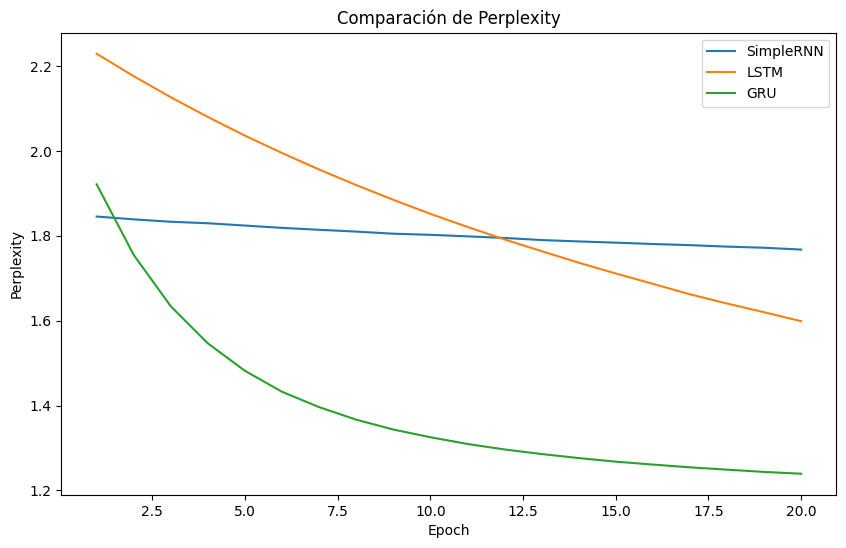

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# epochs
epochs_rnn = range(1, len(history_ppl_rnn) + 1)
epochs_lstm = range(1, len(history_ppl_lstm) + 1)
epochs_gru= range(1, len(history_ppl_gru) + 1)

# gráfico
plt.figure(figsize=(10,6))

sns.lineplot(
    x=epochs_rnn,
    y=history_ppl_rnn,
    label="SimpleRNN"
)

sns.lineplot(
    x=epochs_lstm,
    y=history_ppl_lstm,
    label="LSTM"
)

sns.lineplot(
    x=epochs_gru,
    y=history_ppl_gru,
    label="GRU"
)

plt.xlabel("Epoch")
plt.ylabel("Perplexity")

plt.title("Comparación de Perplexity")

plt.legend()

plt.show()

##Greedy search

In [ ]:
def generate_seq_greedy(model, seed_text, max_length, n_chars):

    output_text = seed_text

    # generar caracteres
    for _ in range(n_chars):

        # encodear texto
        encoded = [
            char2idx[ch]
            for ch in output_text.lower()
            if ch in char2idx
        ]

        # padding
        encoded = pad_sequences(
            [encoded],
            maxlen=max_length,
            padding='pre'
        )

        # predicción
        y_hat = np.argmax(
            model.predict(encoded, verbose=0)[0, -1, :]
        )

        # convertir índice a carácter
        out_char = idx2char[y_hat]

        # concatenar
        output_text += out_char

    return output_text

In [ ]:
model_rnn = keras.models.load_model("model_rnn.keras")
model_lstm = keras.models.load_model("model_lstm.keras")
model_gru = keras.models.load_model("model_gru.keras")

In [ ]:
print("===== SimpleRNN =====\n")

print(generate_seq_greedy(
    model_rnn,
    "love",
    max_context_size,
    100
))

love carry your world come on in i've gotta tell you in my loudest tones that i started looking for a wa


In [ ]:
print("===== LSTM =====\n")

print(generate_seq_greedy(
    model_lstm,
    "love",
    max_context_size,
    100
))

loves lear she ladd want to be a song and all the time she say we we never learn do we so i want to live


In [ ]:
print("===== GRU =====\n")

print(generate_seq_greedy(
    model_gru,
    "love",
    max_context_size,
    100
))

love my boy? i said "where is my boy?" have you seen me before? when i look in your eyes tell me "he had


##Beam search determístico

In [ ]:
def generate_text_beam_search(
    model,
    seed_text,
    max_length,
    n_chars,
    beam_width=3
):

    sequences = [(seed_text, 0)]

    for _ in range(n_chars):

        all_candidates = []

        for seq, score in sequences:

            encoded = [
                char2idx[ch]
                for ch in seq.lower()
                if ch in char2idx
            ]

            encoded = pad_sequences(
                [encoded],
                maxlen=max_length,
                padding='pre'
            )

            probs = model.predict(
                encoded,
                verbose=0
            )[0, -1, :]

            # top k caracteres
            top_k = np.argsort(probs)[-beam_width:]

            for idx in top_k:

                candidate = seq + idx2char[idx]

                candidate_score = score - np.log(probs[idx])

                all_candidates.append(
                    (candidate, candidate_score)
                )

        # ordenar por score
        ordered = sorted(
            all_candidates,
            key=lambda tup: tup[1]
        )

        # quedarnos con los mejores
        sequences = ordered[:beam_width]

    return sequences[0][0]

In [ ]:
seed = "love"
n_chars = 200
beam_width = 5

In [ ]:
print("===== SimpleRNN =====\n")

print(
    generate_text_beam_search(
        model_rnn,
        seed,
        max_context_size,
        n_chars,
        beam_width=beam_width
    )
)

===== SimpleRNN =====

love cause i lied when i was seventeen? why does it always rain on me? is it because i lied when i was seventeen? why does it always rain on me? is it because i lied when i was seventeen? why does it alwa


In [ ]:
print("===== LSTM =====\n")

print(
    generate_text_beam_search(
        model_lstm,
        seed,
        max_context_size,
        n_chars,
        beam_width=beam_width
    )
)

===== LSTM =====

loves that treasure life never felt so alive it's a wonderful life never felt so alive it's a wonderful life never felt so alive it's a wonderful life never felt so alive it's a wonderful life never felt 


In [ ]:
print("===== GRU =====\n")

print(
    generate_text_beam_search(
        model_gru,
        seed,
        max_context_size,
        n_chars,
        beam_width=beam_width
    )
)

===== GRU =====

love to let it go if you never try you'll never know just what you're worth lights will guide you home and ignite your bones and i will try to fix you if you're lost and feel alone circumnavigate the glob


Beam Search permitió generar secuencias más coherentes que greedy search, ya que mantiene múltiples hipótesis simultáneamente durante la generación del texto. Las arquitecturas LSTM y GRU produjeron secuencias más estables y lingüísticamente consistentes respecto de SimpleRNN.

#Beam search estocástico

In [ ]:
def generate_text_temperature(
    model,
    seed_text,
    max_length,
    n_chars,
    temperature=1.0
):

    output_text = seed_text

    for _ in range(n_chars):

        encoded = [
            char2idx[ch]
            for ch in output_text.lower()
            if ch in char2idx
        ]

        encoded = pad_sequences(
            [encoded],
            maxlen=max_length,
            padding='pre'
        )

        probs = model.predict(
            encoded,
            verbose=0
        )[0, -1, :]

        # temperatura
        probs = np.log(probs + 1e-10) / temperature

        probs = np.exp(probs)

        probs = probs / np.sum(probs)

        # sampleo aleatorio
        y_hat = np.random.choice(
            len(probs),
            p=probs
        )

        out_char = idx2char[y_hat]

        output_text += out_char

    return output_text

##Temperatura baja (0.3)
Más conservador y repetitivo.

In [ ]:
print("===== SimpleRNN | Temp = 0.3 =====\n")

print(
    generate_text_temperature(
        model_rnn,
        seed,
        max_context_size,
        n_chars,
        temperature=0.3
    )
)

===== SimpleRNN | Temp = 0.3 =====

love cause you really hurt me 'cause you really hurt me oh you really hurt me 'cause you really hurt me oh you really hurt me 'cause you really hurt me oh you really hurt me 'cause you really hurt me oh y


In [ ]:
print("===== LSTM | Temp = 0.3 =====\n")

print(
    generate_text_temperature(
        model_lstm,
        seed,
        max_context_size,
        n_chars,
        temperature=0.3
    )
)

===== LSTM | Temp = 0.3 =====

loves lear she ladd like a fire, light a fire, a fire, light a fire fun me for you there's nothing to keep them there's nobody listening to what you say it doesn't matter who you are is there anybody else


In [ ]:
print("===== GRU | Temp = 0.3 =====\n")

print(
    generate_text_temperature(
        model_gru,
        seed,
        max_context_size,
        n_chars,
        temperature=0.3
    )
)

===== GRU | Temp = 0.3 =====

love my boy? i said "where is my boy?" have you seen me before? when i look in your eyes tell me "he had to go" said "i seen you before in some kind of a dream? have i seen you before? in some kind of a d


##Temperatura media (1.0)

Balance entre coherencia y creatividad.

In [ ]:
print("===== SimpleRNN | Temp = 1.0 =====\n")

print(
    generate_text_temperature(
        model_rnn,
        seed,
        max_context_size,
        n_chars,
        temperature=1.0
    )
)

===== SimpleRNN | Temp = 1.0 =====

love out you, oh oh oh, oh-oh, you repen you so i want to go, you're a sky full of stars i wanna ride a single stokns something burgwring of clocks who remembers you know i know i was thlo kneas come sork


In [ ]:
print("===== LSTM | Temp = 1.0 =====\n")

print(
    generate_text_temperature(
        model_lstm,
        seed,
        max_context_size,
        n_chars,
        temperature=1.0
    )
)

===== LSTM | Temp = 1.0 =====

loves turn feel the escuts who floating out oooooo. on that i fould. seen a crospira-pown kilfting that i can't decide wrong, all my wrong you diving my feet long and all apart really carrive the world al


In [ ]:
print("===== GRU | Temp = 1.0 =====\n")

print(
    generate_text_temperature(
        model_gru,
        seed,
        max_context_size,
        n_chars,
        temperature=1.0
    )
)

===== GRU | Temp = 1.0 =====

love to listen don't you wanna year every teardrop is a waterfall every tear every tear every teardrop is a waterfall every tear every tear every teardrop is a waterfall every tear every tear every teardr


##Temperatura alta (1.5)

Más creatividad, pero más errores.

In [ ]:
print("===== SimpleRNN | Temp = 1.5 =====\n")

print(
    generate_text_temperature(
        model_rnn,
        seed,
        max_context_size,
        n_chars,
        temperature=1.5
    )
)

===== SimpleRNN | Temp = 1.5 =====

love just a whise 'g eveam tooll cilore to thot you reflapecosoze how sound sometimes you cone? is for you, i know it's gone 2ay down could be gray night everybagion and i saw spack mad so come over to th


In [ ]:
print("===== LSTM | Temp = 1.5 =====\n")

print(
    generate_text_temperature(
        model_lstm,
        seed,
        max_context_size,
        n_chars,
        temperature=1.5
    )
)

===== LSTM | Temp = 1.5 =====

loves le'ver :nsw you but i'de on and on fire i had put no mankest pefters it on her sal it come ner, bal, deating that n'xh a gray before i can bliver that these don't hide much you -xma- miles on me? we


In [ ]:
print("===== GRU | Temp = 1.5 =====\n")

print(
    generate_text_temperature(
        model_gru,
        seed,
        max_context_size,
        n_chars,
        temperature=1.5
    )
)

===== GRU | Temp = 1.5 =====

love to let it go 'cause they're all spies and if we all hide here them do we go tonight i sad of the huvan sleep and if we do you wanna days and i would and baby i, notsing for and, i've seen you befonfo


Se evaluó el efecto de la temperatura durante la generación estocástica de secuencias. Con temperaturas bajas, el modelo generó texto más conservador y repetitivo, privilegiando caracteres de alta probabilidad. En cambio, temperaturas más elevadas aumentaron la diversidad y creatividad de las secuencias generadas, aunque introduciendo mayor cantidad de errores e incoherencias lingüísticas.